## LAB Preprocessing - v2 

- ADCP is **stationary** 
- rsqmb mapping verified: ΔN=0, ΔT=0.0°C

**BT Velocity target naming:**
| Variable | Meaning |
| --- | --- |
| `BT_Vel_pre`    | Mean of velocity components (version 1) - ignored |
| `BT_Vel_stage0` | Unfiltered horizontal magnitude: sqrt(E²+N²) |
| `BT_Vel_stage1` | + direction filter (Step 1)* |
| `BT_Vel_stage2` | + direction + error-velocity filter (Steps 1+3) |
| `BT_Vel_stage3` | + direction + magnitude/outlier filter (Steps 1+2) |
| `BT_Vel_stage4` | + direction + magnitude + error-velocity (Steps 1+2+3 ≈ va2) |

**Lab main target:** `BT_Vel_stage1` 



In [3]:
from scipy.io import loadmat
import pandas as pd
import numpy as np

BEAM_ANGLE_DEG = 25.0
COS_BEAM       = np.cos(np.radians(BEAM_ANGLE_DEG))
ALPHA_ABS      = 0.07
MAX_STEPS      = 1620    # Max ensembles per flow rate (lab)


### Helper: Feature Extractor


In [4]:
def extract_feature(mat_data, struct_name, field_name, is_matrix=True):
    try:
        struct = mat_data[struct_name]
        data   = getattr(struct, field_name)
        if is_matrix:
            if   data.ndim == 1: return data
            elif data.ndim == 2: return np.nanmean(data, axis=0)
            elif data.ndim == 3: return np.nanmean(data, axis=(0, 1))
        else:
            return data
    except Exception as e:
        print(f'  Warning: {struct_name}.{field_name}: {e}')
        return None


### BT Velocity Computation 

**Lab-specific:** ADCP is stationary — BT_E, BT_N are pure apparent bedload velocity.
Direction filter is fully reliable.

**Targets computed:**

- `BT_Vel_stage0`    = sqrt(E²+N²), Use_BT only
- `BT_Vel_stage1` = + direction filter =  Step 1 (**LAB MAIN TARGET**)
- `BT_Vel_stage2` = + error velocity filter = Steps 1+3
- `BT_Vel_stage3` = + magnitude filter = Steps 1+2
- `BT_Vel_stage4` = + magnitude + error = Steps 1+2+3


In [ ]:
def compute_bt_velocity_corrected(mat_data):
    """
    Corrected BT velocity for LAB (stationary) ADCP.
    Returns: BT_Vel_pre, BT_Vel_stage0, BT_Vel_stage1 (LAB MAIN TARGET),
             BT_Vel_stage2, BT_Vel_stage3, BT_Vel_stage4, Error_Velocity
    """
    bt   = mat_data['BottomTrack']
    gen  = mat_data['General']
    summ = mat_data['Summary']
    n    = bt.BT_Vel.shape[0]

    BT_E    = bt.BT_Vel[:, 0]
    BT_N    = bt.BT_Vel[:, 1]
    BT_Diff = bt.BT_Vel[:, 3]   # Error / difference velocity
    UsesBT  = gen.Use_BT.astype(bool)

    # Previous computation (kept for only sensitivity comparison)
    bt_copy = bt.BT_Vel.copy()
    bt_copy[bt_copy < 0] = 0
    BT_Vel_pre = np.nanmean(bt_copy, axis=1)

    # Correct horizontal magnitude
    va_horiz = np.sqrt(BT_E**2 + BT_N**2)

    # ── STEP 1: Direction filter ──────────────────────────────────────────────
    Wv_E = summ.Mean_Vel[:, 0]
    Wv_N = summ.Mean_Vel[:, 1]
    flow_mag   = np.sqrt(Wv_E**2 + Wv_N**2)
    flow_valid = flow_mag > 0.001  # Only filter where flow is measurable
    flow_angle = np.arctan2(Wv_N, Wv_E)
    bt_angle   = np.arctan2(BT_N, BT_E)
    angle_diff = np.abs(np.degrees(flow_angle - bt_angle))
    angle_diff = np.where(angle_diff > 180, 360 - angle_diff, angle_diff)
    direction_ok = (angle_diff < 90.0) | (~flow_valid)

    # ── STEP 2: Magnitude filter  ──────────────────────
    # Remove pings where apparent bedload speed > depth-averaged water speed
    Water_Speed  = np.sqrt(Wv_E**2 + Wv_N**2)
    magnitude_ok = va_horiz < Water_Speed

    # ── STEP 3: Error velocity filter ────────────────────────────────────────
    # In lab: beam inconsistency IS instrument error (reliable filter)
    err_thresh = np.nanmean(np.abs(BT_Diff)) + 2.0 * np.nanstd(BT_Diff)
    error_ok   = np.abs(BT_Diff) < err_thresh

    # ── Compose targets ───────────────────────────────────────────────────────
    mask_raw = UsesBT
    mask_s1  = UsesBT & direction_ok                               # Step 1  = va1
    mask_s2  = UsesBT & direction_ok & error_ok                   # Steps 1+3
    mask_s3  = UsesBT & direction_ok & magnitude_ok               # Steps 1+2
    mask_s4  = UsesBT & direction_ok & magnitude_ok & error_ok    # Steps 1+2+3 ≈ va2

    return {
        'BT_Vel_pre': BT_Vel_pre,
        'BT_Vel_stage0':          np.where(mask_raw, va_horiz, np.nan),
        'BT_Vel_stage1':       np.where(mask_s1,  va_horiz, np.nan),   # LAB MAIN TARGET
        'BT_Vel_stage2':       np.where(mask_s2,  va_horiz, np.nan),
        'BT_Vel_stage3':       np.where(mask_s3,  va_horiz, np.nan),
        'BT_Vel_stage4':       np.where(mask_s4,  va_horiz, np.nan),
        'Error_Velocity':  np.abs(BT_Diff),
        '_stats': {
            'n':        n,
            'n_usebt':  UsesBT.sum(),
            'pct_s1':   100*mask_s1.sum()/n,
            'pct_s2':   100*mask_s2.sum()/n,
            'pct_s3':   100*mask_s3.sum()/n,
            'pct_s4':   100*mask_s4.sum()/n,
        }
    }

### File Paths


In [6]:
BASE = r'C:\Users\thtuh\Documents\MATLAB\new lab big data'

file_paths = {
    'Flow Rate 100': rf'{BASE}\flow rate 100corrected.mat',
    'Flow Rate 120': rf'{BASE}\flow rate 120.mat',
    'Flow Rate 140': rf'{BASE}\flow rate 140.mat',
    'Flow Rate 160': rf'{BASE}\flow rate 160.mat',
    'Flow Rate 180': rf'{BASE}\flow rate 180.mat',
    'Flow Rate 200': rf'{BASE}\flow rate 200.mat',
    'Flow Rate 220': rf'{BASE}\flow rate 220.mat',
    'Flow Rate 240': rf'{BASE}\flow rate 240.mat',
    'Flow Rate 260': rf'{BASE}\flow rate 260.mat',
    'Flow Rate 280': rf'{BASE}\flow rate 280.mat',
    'Flow Rate 300': rf'{BASE}\flow rate 300.mat',
    'Flow Rate 320': rf'{BASE}\flow rate 320.mat',
    'Flow Rate 340': rf'{BASE}\flow rate 340.mat',
    'Flow Rate 360': rf'{BASE}\flow rate 360.mat',
    'Flow Rate 380': rf'{BASE}\flow rate 380.mat',
}
print(f'Flow rates: {list(file_paths.keys())}')


Flow rates: ['Flow Rate 100', 'Flow Rate 120', 'Flow Rate 140', 'Flow Rate 160', 'Flow Rate 180', 'Flow Rate 200', 'Flow Rate 220', 'Flow Rate 240', 'Flow Rate 260', 'Flow Rate 280', 'Flow Rate 300', 'Flow Rate 320', 'Flow Rate 340', 'Flow Rate 360', 'Flow Rate 380']


### Main Processing Loop


In [7]:
all_rows   = []
filt_stats = []

for label, path in file_paths.items():
    try:
        mat = loadmat(path, struct_as_record=False, squeeze_me=True)
    except Exception as e:
        print(f'  SKIP {label}: {e}'); continue

    bt_res = compute_bt_velocity_corrected(mat)
    st     = bt_res['_stats']
    filt_stats.append({
        'Flow Rate':      label,
        'N_total':        st['n'],
        'N_use_BT':       st['n_usebt'],
        'pct_va_stage1':  round(st['pct_s1'], 1),
        'pct_va_stage2':  round(st['pct_s2'], 1),
        'pct_va_stage3':  round(st['pct_s3'], 1),
        'pct_va_stage4':  round(st['pct_s4'], 1),
    })
    print(f'  {label}: N={st["n"]}  '
          f's1={st["pct_s1"]:.0f}%  '
          f's2={st["pct_s2"]:.0f}%  '
          f's3={st["pct_s3"]:.0f}%  '
          f's4={st["pct_s4"]:.0f}%')

    depth   = extract_feature(mat,'Summary',   'Depth',               is_matrix=False)
    mspeed  = extract_feature(mat,'Summary',   'Mean_Speed',          is_matrix=False)
    vstd    = extract_feature(mat,'WaterTrack','Vel_StdDev',          is_matrix=True)
    corr    = extract_feature(mat,'WaterTrack','Correlation',         is_matrix=True)
    vexp    = extract_feature(mat,'WaterTrack','Vel_Expected_StdDev', is_matrix=True)
    snr     = extract_feature(mat,'System',    'SNR',                 is_matrix=True)
    csize   = extract_feature(mat,'System',    'Cell_Size',           is_matrix=False)
    cstart  = extract_feature(mat,'System',    'Cell_Start',          is_matrix=False)

    n_use    = min(bt_res['BT_Vel_stage1'].shape[0], MAX_STEPS)
    bin_dist = (cstart + csize/2.0)/COS_BEAM if (cstart is not None and csize is not None) \
               else np.full(n_use, np.nan)
    rel_abs  = snr + 20*np.log10(np.maximum(bin_dist,0.01)) + 2*ALPHA_ABS*bin_dist \
               if snr is not None else np.full(n_use, np.nan)

    arrays = {
        'BT_Vel_pre': bt_res['BT_Vel_pre'],
        'BT_Vel_stage0':          bt_res['BT_Vel_stage0'],
        'BT_Vel_stage1':       bt_res['BT_Vel_stage1'],
        'BT_Vel_stage2':       bt_res['BT_Vel_stage2'],
        'BT_Vel_stage3':       bt_res['BT_Vel_stage3'],
        'BT_Vel_stage4':       bt_res['BT_Vel_stage4'],
        'Depth': depth, 'Mean_Speed': mspeed,
        'Vel_StdDev': vstd, 'Correlation': corr,
        'Vel_Expected_StdDev': vexp, 'SNR': snr,
        'Bin_Distance': bin_dist,
        'Error_Velocity': bt_res['Error_Velocity'],
        'Cell_Size': csize, 'Cell_Start': cstart,
        'Relative_ABS': rel_abs,
    }
    for i in range(n_use):
        row = {'Flow Rate': label, 'ensemble_idx': i}
        for col, arr in arrays.items():
            row[col] = float(arr[i]) if (arr is not None and len(arr) > i) else np.nan
        all_rows.append(row)

print(f'\nTotal ensembles: {len(all_rows)}')
print(pd.DataFrame(filt_stats).to_string(index=False))


  Flow Rate 100: N=1640  s1=52%  s2=52%  s3=52%  s4=52%
  Flow Rate 120: N=1730  s1=54%  s2=53%  s3=54%  s4=53%
  Flow Rate 140: N=1913  s1=53%  s2=53%  s3=53%  s4=53%
  Flow Rate 160: N=1788  s1=56%  s2=55%  s3=56%  s4=55%
  Flow Rate 180: N=1618  s1=52%  s2=49%  s3=52%  s4=49%
  Flow Rate 200: N=1727  s1=53%  s2=50%  s3=53%  s4=50%
  Flow Rate 220: N=1733  s1=53%  s2=52%  s3=53%  s4=52%
  Flow Rate 240: N=1802  s1=53%  s2=52%  s3=53%  s4=52%
  Flow Rate 260: N=1797  s1=48%  s2=46%  s3=48%  s4=46%
  Flow Rate 280: N=1752  s1=61%  s2=60%  s3=58%  s4=57%
  Flow Rate 300: N=1727  s1=54%  s2=52%  s3=54%  s4=52%
  Flow Rate 320: N=1745  s1=44%  s2=43%  s3=44%  s4=43%
  Flow Rate 340: N=1894  s1=0%  s2=0%  s3=0%  s4=0%
  Flow Rate 360: N=1725  s1=35%  s2=34%  s3=35%  s4=34%
  Flow Rate 380: N=1725  s1=18%  s2=16%  s3=18%  s4=16%

Total ensembles: 24298
    Flow Rate  N_total  N_use_BT  pct_va_stage1  pct_va_stage2  pct_va_stage3  pct_va_stage4
Flow Rate 100     1640      1640           52.0

In [8]:
df = pd.DataFrame(all_rows)
col_order = ['Flow Rate','ensemble_idx',
             'BT_Vel_pre','BT_Vel_stage0',
             'BT_Vel_stage1',   # Step 1  = va1 = LAB MAIN TARGET
             'BT_Vel_stage2',   # Steps 1+3
             'BT_Vel_stage3',   # Steps 1+2
             'BT_Vel_stage4',   # Steps 1+2+3 ≈ va2
             'Depth','Mean_Speed','Vel_StdDev','Correlation',
             'Vel_Expected_StdDev','SNR','Bin_Distance',
             'Error_Velocity','Cell_Size','Cell_Start','Relative_ABS']
df = df[[c for c in col_order if c in df.columns]]
df_clean = df.dropna(subset=['Depth','Mean_Speed'])

print(f'Total rows:      {len(df)}')
print(f'After clean:     {len(df_clean)}')
print(f'\nFiltering retention:')
for col in ['BT_Vel_stage0','BT_Vel_stage1','BT_Vel_stage2','BT_Vel_stage3','BT_Vel_stage4']:
    n_v = df_clean[col].notna().sum()
    print(f'  {col:12s}: {n_v:6d} ({100*n_v/len(df_clean):.1f}%)')
print(f'\nColumns: {df_clean.columns.tolist()}')
print(df_clean.head(3))


Total rows:      24298
After clean:     24298

Filtering retention:
  BT_Vel_stage0:  24298 (100.0%)
  BT_Vel_stage1:  11119 (45.8%)
  BT_Vel_stage2:  10828 (44.6%)
  BT_Vel_stage3:  11047 (45.5%)
  BT_Vel_stage4:  10757 (44.3%)

Columns: ['Flow Rate', 'ensemble_idx', 'BT_Vel_pre', 'BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4', 'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation', 'Vel_Expected_StdDev', 'SNR', 'Bin_Distance', 'Error_Velocity', 'Cell_Size', 'Cell_Start', 'Relative_ABS']
       Flow Rate  ensemble_idx  BT_Vel_pre  BT_Vel_stage0  BT_Vel_stage1  \
0  Flow Rate 100             0    0.000008       0.000312       0.000312   
1  Flow Rate 100             1    0.000147       0.000397            NaN   
2  Flow Rate 100             2    0.000085       0.000346            NaN   

   BT_Vel_stage2  BT_Vel_stage3  BT_Vel_stage4     Depth  Mean_Speed  \
0       0.000312       0.000312       0.000312  0.483866    0.064011   
1            NaN        

In [9]:
OUT = (r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1')
df_clean.to_excel(rf'{OUT}\Processed_Lab_Data_Corrected_v2.xlsx', index=False)
print('Saved: Processed_Lab_Data_Corrected_v2.xlsx')


Saved: Processed_Lab_Data_Corrected_v2.xlsx


### Correlation Heatmap — BT_Vel_stage1


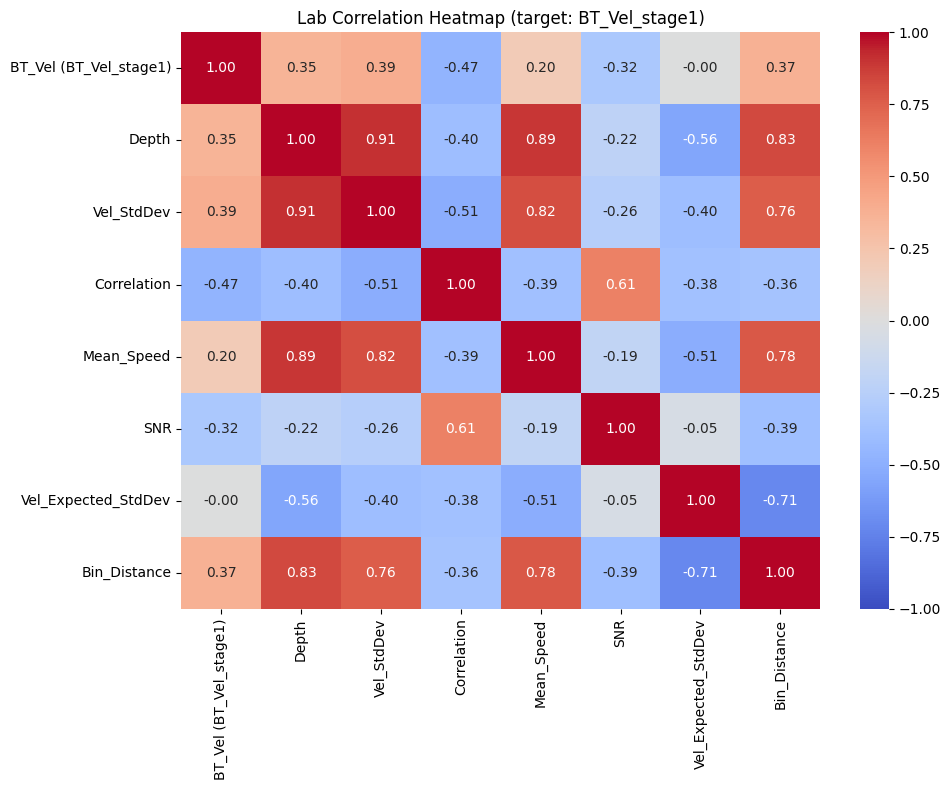

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

feats = ['BT_Vel_stage1','Depth','Vel_StdDev','Correlation',
         'Mean_Speed','SNR','Vel_Expected_StdDev','Bin_Distance']
df_h = df_clean[feats].rename(columns={'BT_Vel_stage1':'BT_Vel (BT_Vel_stage1)'}).dropna()
plt.figure(figsize=(10,8))
sns.heatmap(df_h.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Lab Correlation Heatmap (target: BT_Vel_stage1)')
plt.tight_layout()
plt.savefig('lab_correlation_heatmap.png', dpi=150)
plt.show()


In [11]:
stats = df_clean[['BT_Vel_stage1','Depth','Vel_StdDev','Correlation',
                   'Mean_Speed','SNR','Vel_Expected_StdDev','Bin_Distance',
                   'Error_Velocity','Cell_Size','Cell_Start']]\
               .describe().T[['mean','std','min','max']].round(5)
print('========= LAB STATISTICS (BT_Vel_stage1) =========')
print(stats.to_string())

print('\n========= FILTERING RETENTION =========')
for col in ['BT_Vel_stage0','BT_Vel_stage1','BT_Vel_stage2','BT_Vel_stage3','BT_Vel_stage4']:
    n_v = df_clean[col].notna().sum()
    print(f'  {col:12s}: {n_v:6d} ({100*n_v/len(df_clean):.1f}%)')


========= LAB STATISTICS (BT_Vel_stage1) =========
                         mean      std       min       max
BT_Vel_stage1         0.00770  0.02345   0.00000   0.22584
Depth                 0.54745  0.03631   0.33773   0.90311
Vel_StdDev            0.00106  0.00198   0.00000   0.05543
Correlation          44.50523  4.74664  25.56250  50.57143
Mean_Speed            0.16890  0.07014   0.03968   0.54373
SNR                  44.59563  4.62273  15.39143  60.85625
Vel_Expected_StdDev   0.00681  0.00219   0.00364   0.03304
Bin_Distance          0.12884  0.01264   0.11699   0.19649
Error_Velocity        0.00073  0.00443   0.00000   0.10825
Cell_Size             0.03667  0.01247   0.02500   0.05000
Cell_Start            0.09843  0.00530   0.09353   0.15308

========= FILTERING RETENTION =========
  BT_Vel_stage0:  24298 (100.0%)
  BT_Vel_stage1:  11119 (45.8%)
  BT_Vel_stage2:  10828 (44.6%)
  BT_Vel_stage3:  11047 (45.5%)
  BT_Vel_stage4:  10757 (44.3%)


---
## Backscatter Strength (BS_rel) from `.rsqmb` Raw Files

```
BS_rel [dB] = Bt.Strength + 20·log10(R_BT) + 2·α·R_BT
```
Relative values — no SL0 (RS5 has no pressure sensor).

**Session → Flow Rate mapping (verified ΔN=0, ΔT=0.0°C):**
```
Session 1 (20250224_164912):       FR100–FR200  (T01,T03–T07)
Session 2 (20250225_120414m):      FR220–FR280  (T01–T04)
Session 3 (20250225_152808after):  FR300–FR380  (T01–T05)
```


In [12]:
import zipfile, json as json_lib

def alpha_freshwater(T_C, f_MHz=3.0):
    return 0.0245 * np.exp(-0.0214*T_C) * f_MHz**1.6

def safe_mean(lst):
    vals = [x for x in (lst or []) if x is not None]
    return float(np.mean(vals)) if vals else np.nan


### rsqmb File Mapping

Each `.rsqmb` file contains multiple flow rate.


In [13]:
RSQMB_BASE = r'C:\Users\thtuh\Documents\MATLAB\new lab big data\rsqmb'

RSQMB_MAP = {
    'S1_FR100-200': {
        'file': rf'{RSQMB_BASE}\HS_Bochum_20250224_164912_edited.rsqmb',
        'transects': {
            'AdcpData/01_20250224-120906_Transect_20250224130906/RawData.jsonlog': 'Flow Rate 100',
            'AdcpData/03_20250224-125804_Transect_20250224135804/RawData.jsonlog': 'Flow Rate 120',
            'AdcpData/04_20250224-132809_Transect_20250224142809/RawData.jsonlog': 'Flow Rate 140',
            'AdcpData/05_20250224-140426_Transect_20250224150426/RawData.jsonlog': 'Flow Rate 160',
            'AdcpData/06_20250224-143751_Transect_20250224153751/RawData.jsonlog': 'Flow Rate 180',
            'AdcpData/07_20250224-150805_Transect_20250224160805/RawData.jsonlog': 'Flow Rate 200',
        }
    },

    'S2_FR220-280': {
        'file': rf'{RSQMB_BASE}\HS_Bochum_20250225_120414m.rsqmb',
        'transects': {
            'AdcpData/01_20250225-085321_Transect_20250225095321/RawData.jsonlog': 'Flow Rate 220',
            'AdcpData/02_20250225-092311_Transect_20250225102311/RawData.jsonlog': 'Flow Rate 240',
            'AdcpData/03_20250225-095838_Transect_20250225105838/RawData.jsonlog': 'Flow Rate 260',
            'AdcpData/04_20250225-103059_Transect_20250225113059/RawData.jsonlog': 'Flow Rate 280',
        }
    },

    'S3_FR300-380': {
        'file': rf'{RSQMB_BASE}\HS_Bochum_20250225_152808afterlaunch.rsqmb',
        'transects': {
            'AdcpData/01_20250225-114452_Transect_20250225124452/RawData.jsonlog': 'Flow Rate 300',
            'AdcpData/02_20250225-121842_Transect_20250225131842/RawData.jsonlog': 'Flow Rate 320',
            'AdcpData/03_20250225-125004_Transect_20250225135004/RawData.jsonlog': 'Flow Rate 340',
            'AdcpData/04_20250225-132405_Transect_20250225142405/RawData.jsonlog': 'Flow Rate 360',
            'AdcpData/05_20250225-135645_Transect_20250225145645/RawData.jsonlog': 'Flow Rate 380',
        }
    },
}

print('rsqmb mapping defined.')
print(f'RSQMB directory: {RSQMB_BASE}')
print(f'Campaigns: {list(RSQMB_MAP.keys())}')

total_t = sum(len(v["transects"]) for v in RSQMB_MAP.values())
print(f'Total flow rates mapped: {total_t}')


rsqmb mapping defined.
RSQMB directory: C:\Users\thtuh\Documents\MATLAB\new lab big data\rsqmb
Campaigns: ['S1_FR100-200', 'S2_FR220-280', 'S3_FR300-380']
Total flow rates mapped: 15


**Run this first to verify exact directory names inside each rsqmb.**


In [ ]:

#  Run this to verify exact directory names inside each rsqmb 

for sess, info in RSQMB_MAP.items():
    print(f'\n{sess}')
    try:
        with zipfile.ZipFile(info['file']) as z:
            inside = set([n for n in z.namelist() if n.endswith('RawData.jsonlog')])
            for jl in sorted(inside):
                print(f'  FOUND: {jl}')
        for jl, fr in info['transects'].items():
            ok = '✅' if jl in inside else '❌ WRONG PATH'
            print(f'  {ok} {fr}: {jl}')
    except Exception as e:
        print(f'  ERROR: {e}')



S1_FR100-200
  FOUND: AdcpData/01_20250224-120906_Transect_20250224130906/RawData.jsonlog
  FOUND: AdcpData/02_20250224-125602_Transect_20250224135602/RawData.jsonlog
  FOUND: AdcpData/03_20250224-125804_Transect_20250224135804/RawData.jsonlog
  FOUND: AdcpData/04_20250224-132809_Transect_20250224142809/RawData.jsonlog
  FOUND: AdcpData/05_20250224-140426_Transect_20250224150426/RawData.jsonlog
  FOUND: AdcpData/06_20250224-143751_Transect_20250224153751/RawData.jsonlog
  FOUND: AdcpData/07_20250224-150805_Transect_20250224160805/RawData.jsonlog
  FOUND: AdcpData/08_20250224-154054_Transect_20250224164054/RawData.jsonlog
  ✅ Flow Rate 100: AdcpData/01_20250224-120906_Transect_20250224130906/RawData.jsonlog
  ✅ Flow Rate 120: AdcpData/03_20250224-125804_Transect_20250224135804/RawData.jsonlog
  ✅ Flow Rate 140: AdcpData/04_20250224-132809_Transect_20250224142809/RawData.jsonlog
  ✅ Flow Rate 160: AdcpData/05_20250224-140426_Transect_20250224150426/RawData.jsonlog
  ✅ Flow Rate 180: Adc

### BS_rel Extraction Function

In [15]:
def extract_bs_from_rsqmb(rsqmb_path, jl_path_in_zip):
    rows = []
    with zipfile.ZipFile(rsqmb_path) as z:
        with z.open(jl_path_in_zip) as f:
            for line in f.read().decode('utf-8-sig').splitlines():
                parts = line.strip().split(',', 3)
                if len(parts) < 4 or parts[0] != 'RiverSample': continue
                s  = json_lib.loads(parts[3])
                bt = s.get('Bt', {})
                rows.append({'ensemble_idx': len(rows),
                    'EI_mean':     safe_mean(bt.get('Strength (dB)')),
                    'R_BT_mean':   safe_mean([x for x in (bt.get('Range (m)') or []) if x and x>0.01]),
                    'Bt_Contrast': safe_mean(bt.get('Contrast (dB)')),
                    'VB_Strength': s.get('Vb',{}).get('Strength (dB)', np.nan),
                    'T_rsqmb':     s.get('Sensors',{}).get('Temperature (C)', np.nan)})
    if not rows: return pd.DataFrame()
    df = pd.DataFrame(rows)
    df['alpha']   = df['T_rsqmb'].apply(lambda t: alpha_freshwater(t) if pd.notna(t) else np.nan)
    df['TL_2way'] = 20*np.log10(np.maximum(df['R_BT_mean'],0.01)) + 2*df['alpha']*df['R_BT_mean']
    df['BS_rel']  = df['EI_mean'] + df['TL_2way']
    return df


### Extract BS_rel — All 15 Flow Rates


In [16]:
bs_all = []
print(f'{"Flow Rate":<16} {"N":>5} {"EI_mean":>8} {"R_BT":>7} {"BS_rel":>8} {"Contrast":>9} {"T°C":>5}')
print('-'*65)
for sess, info in RSQMB_MAP.items():
    for jl_path, fr_label in info['transects'].items():
        try:
            df_bs = extract_bs_from_rsqmb(info['file'], jl_path)
            if df_bs.empty: print(f'  {fr_label}: EMPTY'); continue
            df_bs.insert(0, 'Flow Rate', fr_label)
            bs_all.append(df_bs)
            print(f'  {fr_label:<14} {len(df_bs):>5} '
                  f'{df_bs["EI_mean"].mean():>8.1f} {df_bs["R_BT_mean"].mean():>7.3f} '
                  f'{df_bs["BS_rel"].mean():>8.1f} {df_bs["Bt_Contrast"].mean():>9.1f} '
                  f'{df_bs["T_rsqmb"].mean():>5.1f}°C')
        except Exception as e:
            print(f'  {fr_label}: ERROR — {e}')

df_bs_all = pd.concat(bs_all, ignore_index=True) if bs_all else pd.DataFrame()
if not df_bs_all.empty:
    print(f'\nTotal: {len(df_bs_all)} | BS_rel valid: {df_bs_all["BS_rel"].notna().sum()}')


Flow Rate            N  EI_mean    R_BT   BS_rel  Contrast   T°C
-----------------------------------------------------------------
  Flow Rate 100   1640     41.1   0.443     34.1      34.5  13.9°C
  Flow Rate 120   1730     39.2   0.453     32.4      32.4  14.0°C
  Flow Rate 140   1913     38.9   0.465     32.3      31.9  14.2°C
  Flow Rate 160   1788     38.8   0.476     32.5      32.2  14.3°C
  Flow Rate 180   1618     38.8   0.485     32.6      31.7  14.4°C
  Flow Rate 200   1727     38.3   0.493     32.2      31.1  14.6°C
  Flow Rate 220   1733     36.3   0.499     30.4      28.5  14.6°C
  Flow Rate 240   1802     31.6   0.508     25.8      25.7  14.9°C
  Flow Rate 260   1797     34.5   0.517     28.9      19.3  15.2°C
  Flow Rate 280   1752     42.3   0.521     36.8      16.5  15.6°C
  Flow Rate 300   1727     30.4   0.532     25.0      20.2  16.1°C
  Flow Rate 320   1745     43.2   0.536     37.9      14.8  16.5°C
  Flow Rate 340   1894     52.2   0.549     47.1      12.4  17.0°

### Merge BS_rel into Main DataFrame and Save Final Output


In [17]:
bs_cols = ['Flow Rate','ensemble_idx','EI_mean','R_BT_mean','Bt_Contrast','VB_Strength','BS_rel']
df_final = pd.merge(df_clean, df_bs_all[bs_cols],
                    on=['Flow Rate','ensemble_idx'], how='left') \
           if not df_bs_all.empty else df_clean.copy()

col_final = ['Flow Rate','ensemble_idx',
             'BT_Vel_pre','BT_Vel_stage0','BT_Vel_stage1','BT_Vel_stage2','BT_Vel_stage3','BT_Vel_stage4',
             'Depth','Mean_Speed','Vel_StdDev','Correlation',
             'Vel_Expected_StdDev','SNR','Bin_Distance',
             'Error_Velocity','Cell_Size','Cell_Start',
             'BS_rel','EI_mean','Bt_Contrast','VB_Strength','R_BT_mean',
             'Relative_ABS']
df_final = df_final[[c for c in col_final if c in df_final.columns]]

OUT = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1'
df_final.to_excel(rf'{OUT}\Processed_LAB_Data_with_BS.xlsx', index=False)
print(f'Saved: Processed_Lab_Data_FINAL.xlsx | Shape: {df_final.shape}')
print(f'\n--- Column coverage ---')
for col in df_final.columns:
    n_v = df_final[col].notna().sum()
    print(f'  {col:<25}: {n_v:6d} ({100*n_v/len(df_final):.0f}%)')


Saved: Processed_Lab_Data_FINAL.xlsx | Shape: (24298, 24)

--- Column coverage ---
  Flow Rate                :  24298 (100%)
  ensemble_idx             :  24298 (100%)
  BT_Vel_pre               :  24298 (100%)
  BT_Vel_stage0            :  24298 (100%)
  BT_Vel_stage1            :  11119 (46%)
  BT_Vel_stage2            :  10828 (45%)
  BT_Vel_stage3            :  11047 (45%)
  BT_Vel_stage4            :  10757 (44%)
  Depth                    :  24298 (100%)
  Mean_Speed               :  24298 (100%)
  Vel_StdDev               :  24298 (100%)
  Correlation              :  24298 (100%)
  Vel_Expected_StdDev      :  24298 (100%)
  SNR                      :  24298 (100%)
  Bin_Distance             :  24298 (100%)
  Error_Velocity           :  24298 (100%)
  Cell_Size                :  24298 (100%)
  Cell_Start               :  24298 (100%)
  BS_rel                   :  23395 (96%)
  EI_mean                  :  23395 (96%)
  Bt_Contrast              :  23395 (96%)
  VB_Strength        

### Validation Plots


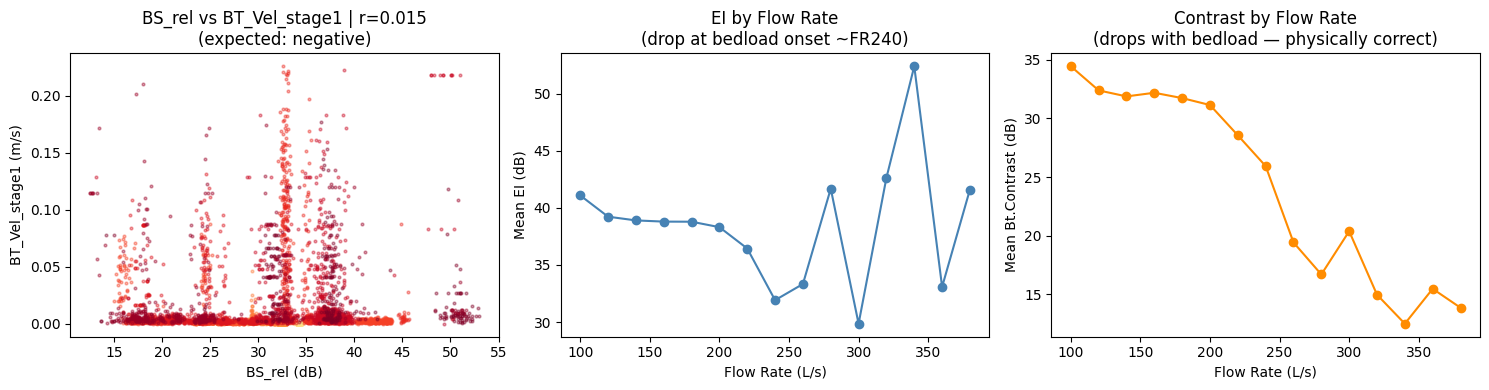

In [18]:
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# 1. BS_rel vs BT_Vel_stage1
if 'BS_rel' in df_final.columns:
    v = df_final[['BS_rel','BT_Vel_stage1']].dropna()
    r, p = scipy_stats.pearsonr(v['BS_rel'], v['BT_Vel_stage1'])
    frs = sorted(df_final['Flow Rate'].unique(), key=lambda x: int(x.split()[-1]))
    cm  = plt.cm.YlOrRd(np.linspace(0.2,1,len(frs)))
    for i,fr in enumerate(frs):
        sub = df_final[df_final['Flow Rate']==fr][['BS_rel','BT_Vel_stage1']].dropna()
        axes[0].scatter(sub['BS_rel'], sub['BT_Vel_stage1'], s=4, alpha=0.4, color=cm[i])
    axes[0].set_xlabel('BS_rel (dB)'); axes[0].set_ylabel('BT_Vel_stage1 (m/s)')
    axes[0].set_title(f'BS_rel vs BT_Vel_stage1 | r={r:.3f}\n(expected: negative)')

# 2. EI_mean by flow rate
if 'EI_mean' in df_final.columns:
    fr_ei  = df_final.groupby('Flow Rate')['EI_mean'].mean()
    fr_nums = [int(fr.split()[-1]) for fr in fr_ei.index]
    axes[1].plot(fr_nums, fr_ei.values, 'o-', color='steelblue')
    axes[1].set_xlabel('Flow Rate (L/s)'); axes[1].set_ylabel('Mean EI (dB)')
    axes[1].set_title('EI by Flow Rate\n(drop at bedload onset ~FR240)')

# 3. Bt_Contrast by flow rate
if 'Bt_Contrast' in df_final.columns:
    fr_ct   = df_final.groupby('Flow Rate')['Bt_Contrast'].mean()
    fr_nums = [int(fr.split()[-1]) for fr in fr_ct.index]
    axes[2].plot(fr_nums, fr_ct.values, 'o-', color='darkorange')
    axes[2].set_xlabel('Flow Rate (L/s)'); axes[2].set_ylabel('Mean Bt.Contrast (dB)')
    axes[2].set_title('Contrast by Flow Rate\n(drops with bedload — physically correct)')

plt.tight_layout()
plt.savefig('lab_bs_validation.png', dpi=150)
plt.show()
